# Spherical Anomaly Signature

In [1]:
import sys, os, numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ── locate master\ from examples\<name>\ (two levels up) ─────────────────
MASTER = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', '..'))

sys.path.insert(0, os.path.join(MASTER, 'io'))
sys.path.insert(0, os.path.join(MASTER, 'io', 'inputs'))
sys.path.insert(0, os.path.join(MASTER, 'io', 'outputs'))

# inputs
from survey import GPRSurvey
from anomalies import SphereAnomaly

# runner
from pathlib import Path
from runner import ProjectPaths, run_tetgen, run_solver

# outputs
from fieldreader import AnalyticalLoader, ElfeLoader, CSVFieldLoader, GPRDataset
from postprocess import field_error, field_simple_error, error_stats
from visualize   import (ReceiverLinePlot, ReceiverLineErrorPlot,
                          ReceiverLineCombined, ErrorHistogramPlot, 
                          ReceiverLineSimpleErrorPlot, SimpleErrorHistogramPlot)

# ── set once per machine ───────────────────────────────────────────────────
paths = ProjectPaths(
    master_dir = MASTER,
    exec_rel   = r'elfe3D_GPR\elfe3d_gpr',
    use_wsl    = True,   # False if running from inside WSL
)

print('master   :', MASTER)
print('exec     :', paths.exec_path())

master   : f:\Projects\EMGeoInversion\elfe3D_GPR
exec     : f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\elfe3d_gpr


## Half-Space Solution

In [2]:
output_dir = Path(paths.master_dir) / Path("elfe3D_GPR") / Path("out_homogeneous_earth")
result_txt = output_dir / Path('electric_fields_receiver_line.txt')
print('reading:', result_txt)

ef_hs = ElfeLoader(
    filepath    = str(result_txt),
    label       = 'elfe3D_GPR Half-Space',
    num_endfire = 48,
).endfire()

print(f'r : {ef_hs.r.min():.3f} - {ef_hs.r.max():.3f} m   ({len(ef_hs.r)} receivers)')

reading: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\out_homogeneous_earth\electric_fields_receiver_line.txt
r : 0.100 - 1.000 m   (48 receivers)


## Sphere in Half-Space Solution

In [3]:
output_dir = Path(paths.master_dir) / Path("elfe3D_GPR") / Path("out_anomaly_sphere_hs")
result_txt = output_dir / Path('electric_fields_receiver_line.txt')
print('reading:', result_txt)

ef_s_hs = ElfeLoader(
    filepath    = str(result_txt),
    label       = 'elfe3D_GPR Sphere in Half-Space',
    num_endfire = 48,
).endfire()

print(f'r : {ef_s_hs.r.min():.3f} - {ef_s_hs.r.max():.3f} m   ({len(ef_s_hs.r)} receivers)')

reading: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\out_anomaly_sphere_hs\electric_fields_receiver_line.txt
r : 0.100 - 1.000 m   (48 receivers)


In [4]:
# Difference: Sphere in Half-Space - Half-Space (Sphere Signature)
diff_hs_amp = field_simple_error(ef_hs, ef_s_hs, 0)
diff_hs_phase = field_simple_error(ef_hs, ef_s_hs, 1)
diff_hs_real = field_simple_error(ef_hs, ef_s_hs, 2)
diff_hs_imag = field_simple_error(ef_hs, ef_s_hs, 3)

print("Half-Space Sphere Signature:")
print(f"  Amplitude diff: mean={np.nanmean(diff_hs_amp):.4e}, max={np.nanmax(diff_hs_amp):.4e}")
print(f"  Phase diff:     mean={np.nanmean(diff_hs_phase):.4e}, max={np.nanmax(diff_hs_phase):.4e}")
print(f"  Real diff:      mean={np.nanmean(diff_hs_real):.4e}, max={np.nanmax(diff_hs_real):.4e}")
print(f"  Imag diff:      mean={np.nanmean(diff_hs_imag):.4e}, max={np.nanmax(diff_hs_imag):.4e}")

Half-Space Sphere Signature:
  Amplitude diff: mean=5.9881e+00, max=6.5937e+01
  Phase diff:     mean=-9.0276e-03, max=3.5576e-03
  Real diff:      mean=3.6242e+00, max=7.5903e+00
  Imag diff:      mean=4.9739e+00, max=6.5849e+01


## Two-Layered Earth Solution

In [5]:
output_dir = Path(paths.master_dir) / Path("elfe3D_GPR") / Path("out_two_layered_earth")
result_txt = output_dir / Path('electric_fields_receiver_line.txt')
print('reading:', result_txt)

ef_tl = ElfeLoader(
    filepath    = str(result_txt),
    label       = 'elfe3D_GPR Two-Layered Earth',
    num_endfire = 48,
).endfire()

print(f'r : {ef_tl.r.min():.3f} - {ef_tl.r.max():.3f} m   ({len(ef_tl.r)} receivers)')

reading: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\out_two_layered_earth\electric_fields_receiver_line.txt
r : 0.100 - 1.000 m   (48 receivers)


## Sphere in Two-Layered Earth Solution

In [6]:
output_dir = Path(paths.master_dir) / Path("elfe3D_GPR") / Path("out_anomaly_sphere")
result_txt = output_dir / Path('electric_fields_receiver_line.txt')
print('reading:', result_txt)

ef_s_tl = ElfeLoader(
    filepath    = str(result_txt),
    label       = 'elfe3D_GPR Sphere in Two-Layered Earth',
    num_endfire = 48,
).endfire()

print(f'r : {ef_s_tl.r.min():.3f} - {ef_s_tl.r.max():.3f} m   ({len(ef_s_tl.r)} receivers)')

reading: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\out_anomaly_sphere\electric_fields_receiver_line.txt
r : 0.100 - 1.000 m   (48 receivers)


In [7]:
# Difference: Sphere in Two-Layered - Two-Layered (Sphere Signature)
diff_tl_amp = field_simple_error(ef_tl, ef_s_tl, 0)
diff_tl_phase = field_simple_error(ef_tl, ef_s_tl, 1)
diff_tl_real = field_simple_error(ef_tl, ef_s_tl, 2)
diff_tl_imag = field_simple_error(ef_tl, ef_s_tl, 3)

print("Two-Layered Sphere Signature:")
print(f"  Amplitude diff: mean={np.nanmean(diff_tl_amp):.4e}, max={np.nanmax(diff_tl_amp):.4e}")
print(f"  Phase diff:     mean={np.nanmean(diff_tl_phase):.4e}, max={np.nanmax(diff_tl_phase):.4e}")
print(f"  Real diff:      mean={np.nanmean(diff_tl_real):.4e}, max={np.nanmax(diff_tl_real):.4e}")
print(f"  Imag diff:      mean={np.nanmean(diff_tl_imag):.4e}, max={np.nanmax(diff_tl_imag):.4e}")

Two-Layered Sphere Signature:
  Amplitude diff: mean=6.7570e+00, max=4.0578e+01
  Phase diff:     mean=-1.1300e-01, max=1.0458e-01
  Real diff:      mean=4.1945e+00, max=6.9198e+00
  Imag diff:      mean=5.7157e+00, max=4.0492e+01


## $miepython$ Sphere Solution

In [8]:
# Load miepython sphere solution (analytical scattering from sphere in half-space)
MIE_DATA_DIR = os.path.join(MASTER, 'data', 'data_miepython')

mie = CSVFieldLoader(
    filepath=os.path.join(MIE_DATA_DIR, 'endfire_electric_field.csv'),
    label='miepython (Analytical Sphere)',
    distance_col='Distance (m)',
    orientation='Endfire'
).ex()

print(f'miepython r : {mie.r.min():.3f} - {mie.r.max():.3f} m   ({len(mie.r)} receivers)')
print(f'elfe3D sphere (hs) r: {ef_s_hs.r.min():.3f} - {ef_s_hs.r.max():.3f} m   ({len(ef_s_hs.r)} receivers)')

miepython r : 0.100 - 1.000 m   (48 receivers)
elfe3D sphere (hs) r: 0.100 - 1.000 m   (48 receivers)


## Comparison

In [9]:
# Normalize all datasets to compare shapes (scale to max amplitude = 1)
def normalize_dataset(ds: GPRDataset, suffix: str = "(norm)") -> GPRDataset:
    """Normalize amplitude, real, imag to same max; phase unchanged."""
    max_val = max(np.abs(ds.amp).max(), np.abs(ds.real).max(), np.abs(ds.imag).max())
    if max_val == 0:
        return ds
    return GPRDataset(
        amp=ds.amp / max_val,
        phase=ds.phase,
        real=ds.real / max_val,
        imag=ds.imag / max_val,
        orientation=ds.orientation,
        r=ds.r,
        label=f"{ds.label} {suffix}"
    )

# Normalize all three datasets
mie_norm = normalize_dataset(mie)
ef_s_hs_norm = normalize_dataset(ef_s_hs)
ef_hs_norm = normalize_dataset(ef_hs)

print("Normalized datasets:")
print(f"  miepython max amp: {mie_norm.amp.max():.4f}")
print(f"  elfe3D sphere (hs) max amp: {ef_s_hs_norm.amp.max():.4f}")
print(f"  elfe3D half-space max amp: {ef_hs_norm.amp.max():.4f}")

Normalized datasets:
  miepython max amp: 1.0000
  elfe3D sphere (hs) max amp: 1.0000
  elfe3D half-space max amp: 1.0000


## Overlapped Subplots

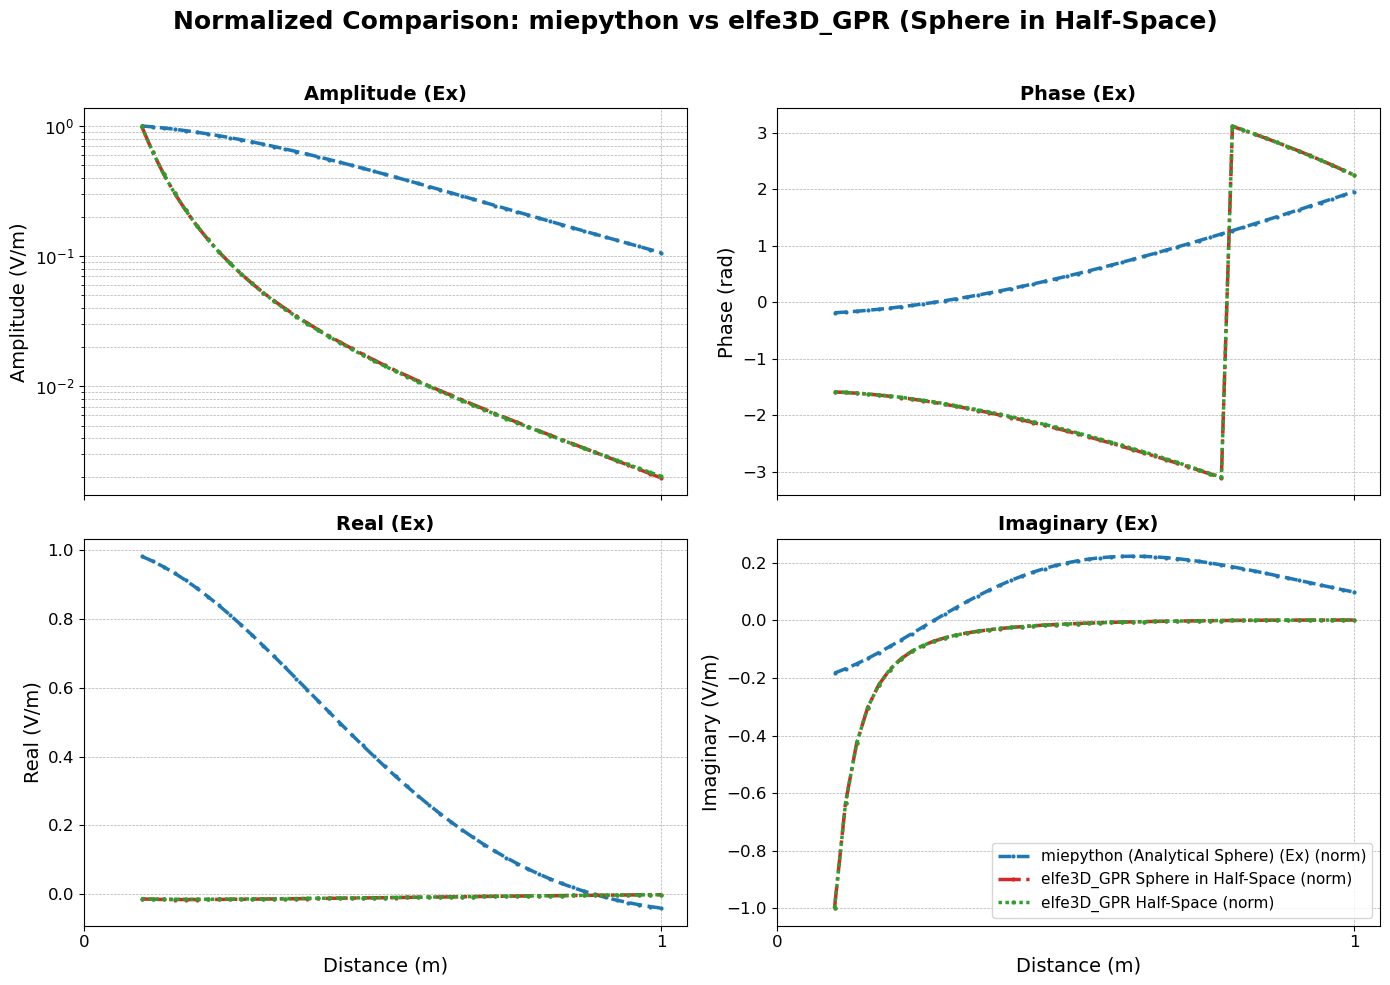

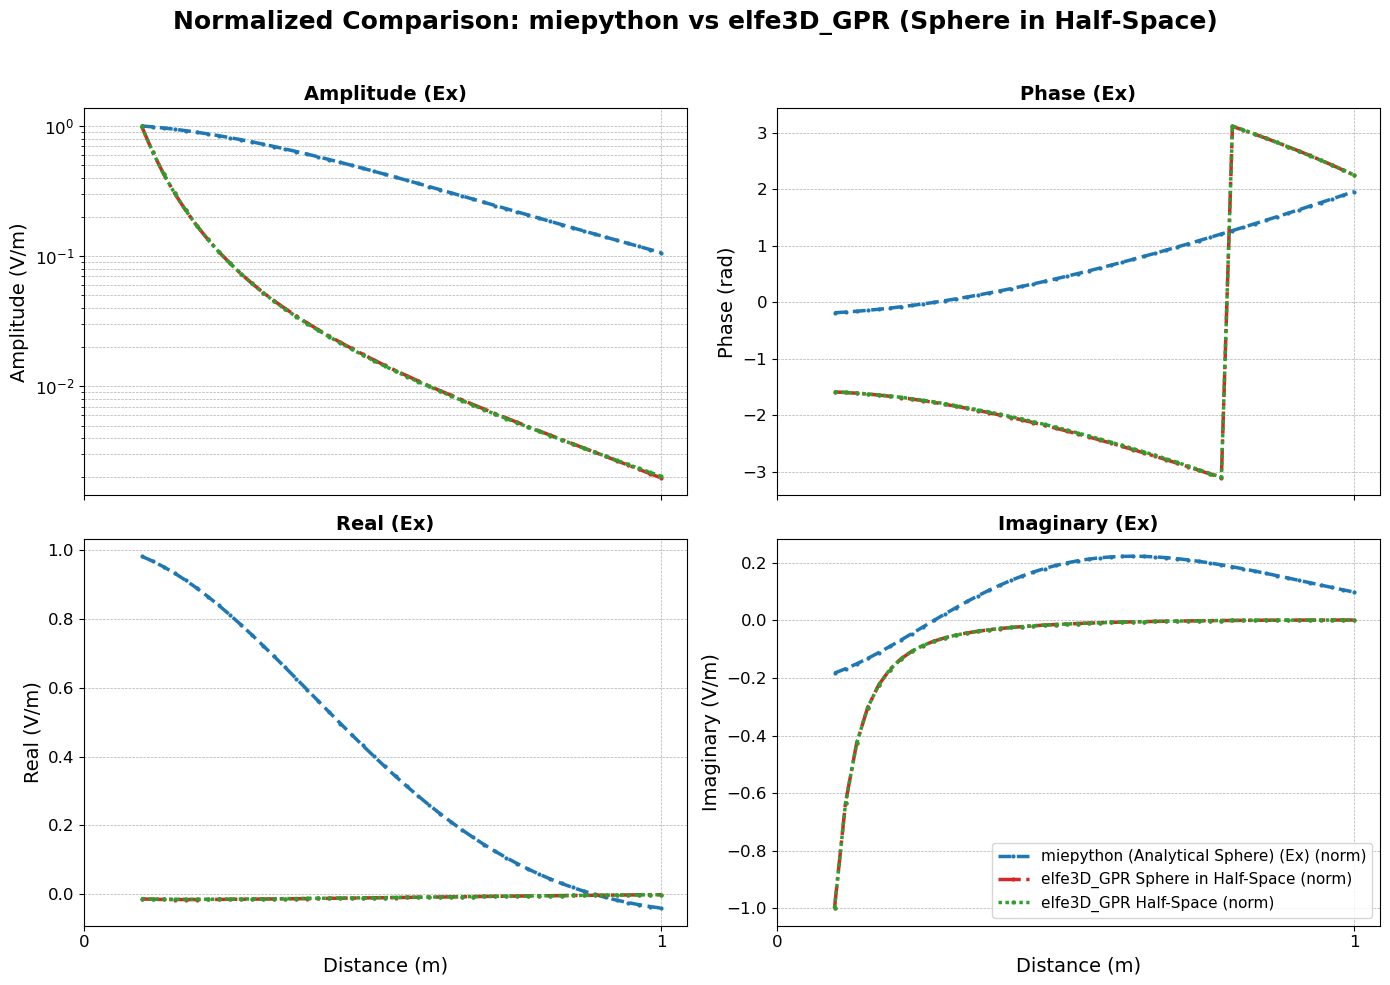

In [10]:
# Plot normalized comparison: miepython vs elfe3D sphere vs half-space background
ReceiverLinePlot(
    datasets=[mie_norm, ef_s_hs_norm, ef_hs_norm],
    base_lw=2.5,
    font={"suptitle": 18, "label": 14, "tick": 12, "legend": 11},
    figsize=(14, 10)
).plot(suptitle="Normalized Comparison: miepython vs elfe3D_GPR (Sphere in Half-Space)")

## Difference: elfe3D sphere vs miepython

In [11]:
# Compute error between elfe3D sphere solution and miepython analytical solution
# Note: may need to interpolate if receiver grids differ
print("elfe3D_GPR Sphere vs miepython (Analytical):")
print(f"  miepython r range: {mie.r.min():.3f} - {mie.r.max():.3f} m")
print(f"  elfe3D sphere r range: {ef_s_hs.r.min():.3f} - {ef_s_hs.r.max():.3f} m")

# Use field_simple_error to compute absolute difference
diff_mie_amp = field_simple_error(mie, ef_s_hs, 0)
diff_mie_phase = field_simple_error(mie, ef_s_hs, 1)
diff_mie_real = field_simple_error(mie, ef_s_hs, 2)
diff_mie_imag = field_simple_error(mie, ef_s_hs, 3)

print(f"\n  Amplitude diff: mean={np.nanmean(diff_mie_amp):.4e}, max={np.nanmax(diff_mie_amp):.4e}")
print(f"  Phase diff:     mean={np.nanmean(diff_mie_phase):.4e}, max={np.nanmax(diff_mie_phase):.4e}")
print(f"  Real diff:      mean={np.nanmean(diff_mie_real):.4e}, max={np.nanmax(diff_mie_real):.4e}")
print(f"  Imag diff:      mean={np.nanmean(diff_mie_imag):.4e}, max={np.nanmax(diff_mie_imag):.4e}")

elfe3D_GPR Sphere vs miepython (Analytical):
  miepython r range: 0.100 - 1.000 m
  elfe3D sphere r range: 0.100 - 1.000 m

  Amplitude diff: mean=5.6220e+11, max=1.2156e+12
  Phase diff:     mean=-1.6504e+00, max=1.8431e+00
  Real diff:      mean=4.8399e+11, max=1.1951e+12
  Imag diff:      mean=1.8156e+11, max=2.7156e+11


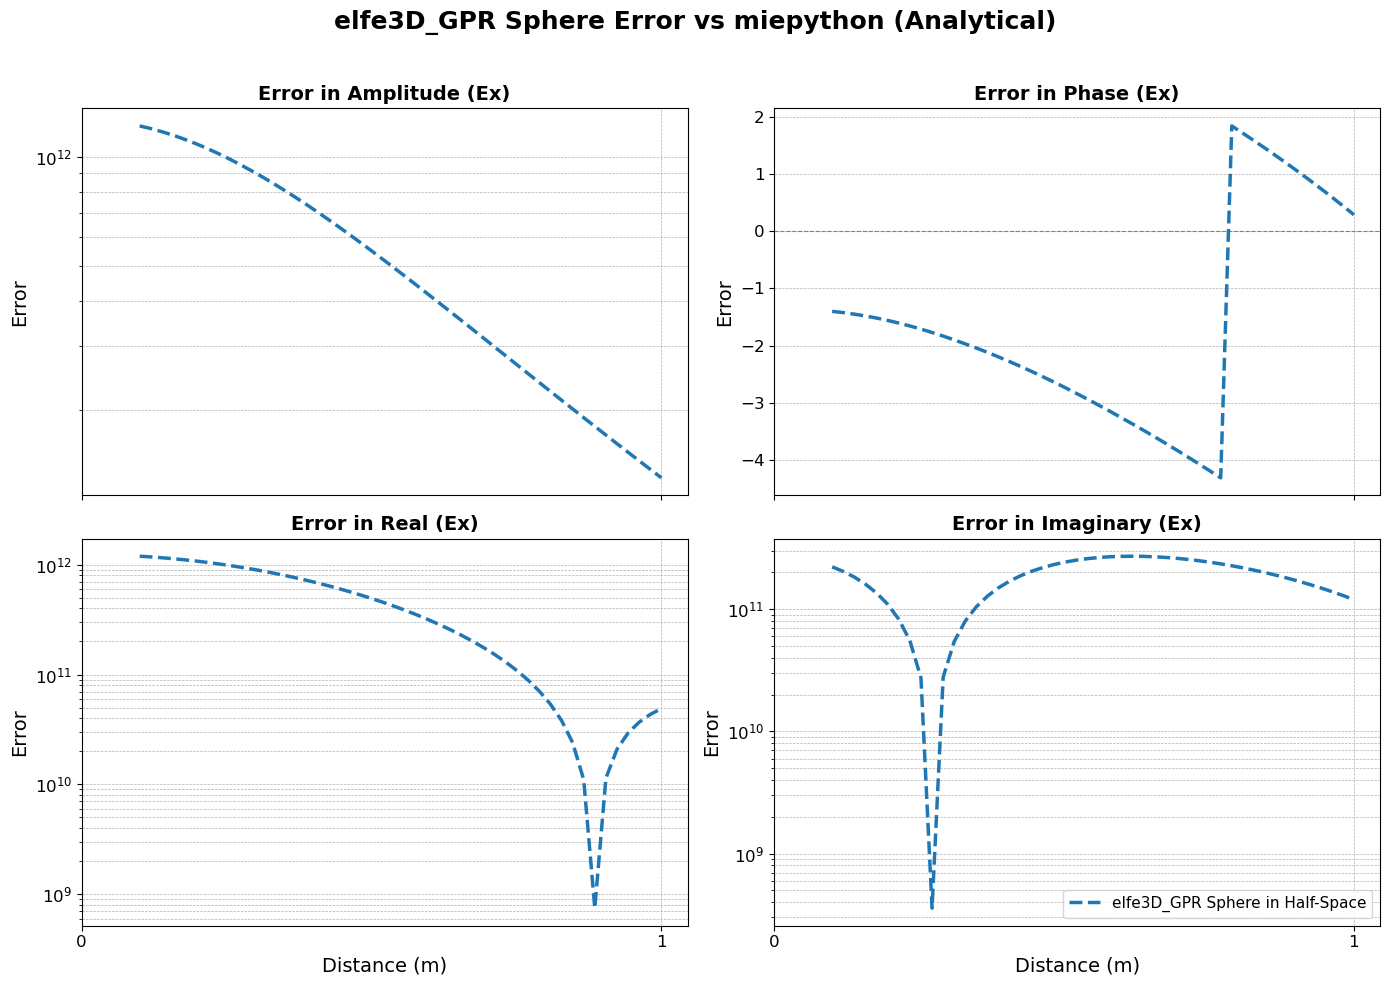

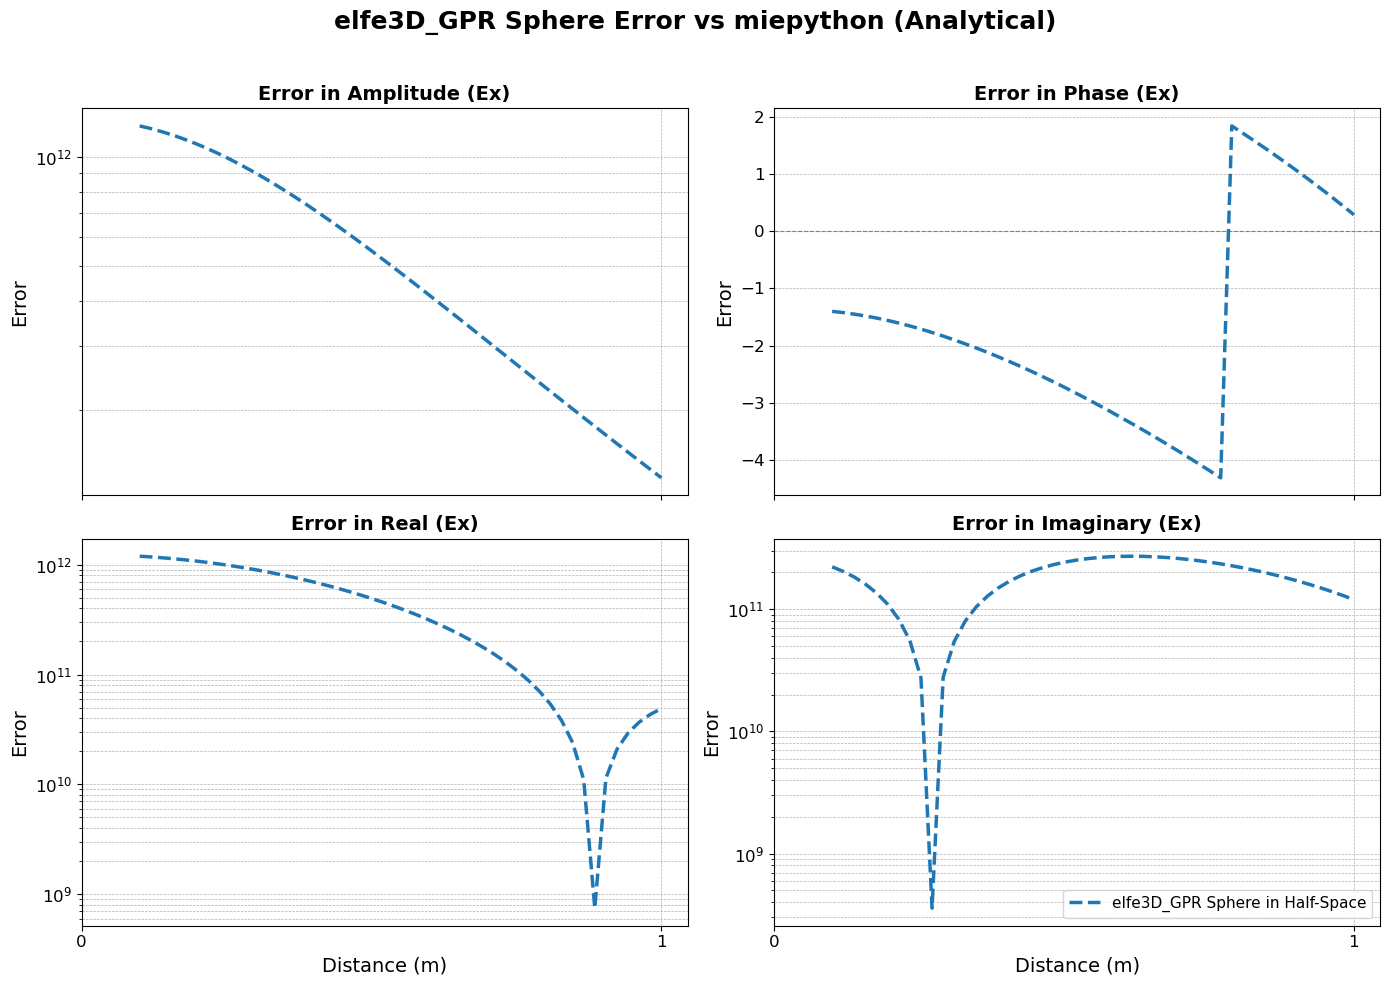

In [12]:
# Plot error: elfe3D sphere vs miepython
ReceiverLineSimpleErrorPlot(
    datasets=[ef_s_hs],
    reference=mie,
    base_lw=2.5,
    font={"suptitle": 18, "label": 14, "tick": 12, "legend": 11},
    figsize=(14, 10)
).plot(suptitle="elfe3D_GPR Sphere Error vs miepython (Analytical)")

# Spherical Anomaly Signature

In [13]:
import sys, os, numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ── locate master\ from examples\<name>\ (two levels up) ─────────────────
MASTER = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', '..'))

sys.path.insert(0, os.path.join(MASTER, 'io'))
sys.path.insert(0, os.path.join(MASTER, 'io', 'inputs'))
sys.path.insert(0, os.path.join(MASTER, 'io', 'outputs'))

# inputs
from survey import GPRSurvey
from anomalies import SphereAnomaly

# runner
from pathlib import Path
from runner import ProjectPaths, run_tetgen, run_solver

# outputs
from fieldreader import AnalyticalLoader, ElfeLoader, CSVFieldLoader, GPRDataset
from postprocess import field_error, field_simple_error, error_stats
from visualize   import (ReceiverLinePlot, ReceiverLineErrorPlot,
                          ReceiverLineCombined, ErrorHistogramPlot, 
                          ReceiverLineSimpleErrorPlot, SimpleErrorHistogramPlot)

# ── set once per machine ───────────────────────────────────────────────────
paths = ProjectPaths(
    master_dir = MASTER,
    exec_rel   = r'elfe3D_GPR\elfe3d_gpr',
    use_wsl    = True,   # False if running from inside WSL
)

print('master   :', MASTER)
print('exec     :', paths.exec_path())

master   : f:\Projects\EMGeoInversion\elfe3D_GPR
exec     : f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\elfe3d_gpr


## Half-Space Solution

In [14]:
output_dir = Path(paths.master_dir) / Path("elfe3D_GPR") / Path("out_homogeneous_earth")
result_txt = output_dir / Path('electric_fields_receiver_line.txt')
print('reading:', result_txt)

ef_hs = ElfeLoader(
    filepath    = str(result_txt),
    label       = 'elfe3D_GPR Half-Space',
    num_endfire = 48,
).endfire()

print(f'r : {ef_hs.r.min():.3f} - {ef_hs.r.max():.3f} m   ({len(ef_hs.r)} receivers)')


reading: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\out_homogeneous_earth\electric_fields_receiver_line.txt
r : 0.100 - 1.000 m   (48 receivers)


## Sphere in Half-Space Solution

In [15]:
output_dir = Path(paths.master_dir) / Path("elfe3D_GPR") / Path("out_anomaly_sphere_hs")
result_txt = output_dir / Path('electric_fields_receiver_line.txt')
print('reading:', result_txt)

ef_s_hs = ElfeLoader(
    filepath    = str(result_txt),
    label       = 'elfe3D_GPR Sphere in Half-Space',
    num_endfire = 48,
).endfire()

print(f'r : {ef_s_hs.r.min():.3f} - {ef_s_hs.r.max():.3f} m   ({len(ef_s_hs.r)} receivers)')


reading: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\out_anomaly_sphere_hs\electric_fields_receiver_line.txt
r : 0.100 - 1.000 m   (48 receivers)


In [16]:
# Difference: Sphere in Half-Space - Half-Space (Sphere Signature)
diff_hs_amp = field_simple_error(ef_hs, ef_s_hs, 0)
diff_hs_phase = field_simple_error(ef_hs, ef_s_hs, 1)
diff_hs_real = field_simple_error(ef_hs, ef_s_hs, 2)
diff_hs_imag = field_simple_error(ef_hs, ef_s_hs, 3)

print("Half-Space Sphere Signature:")
print(f"  Amplitude diff: mean={np.nanmean(diff_hs_amp):.4e}, max={np.nanmax(diff_hs_amp):.4e}")
print(f"  Phase diff:     mean={np.nanmean(diff_hs_phase):.4e}, max={np.nanmax(diff_hs_phase):.4e}")
print(f"  Real diff:      mean={np.nanmean(diff_hs_real):.4e}, max={np.nanmax(diff_hs_real):.4e}")
print(f"  Imag diff:      mean={np.nanmean(diff_hs_imag):.4e}, max={np.nanmax(diff_hs_imag):.4e}")

Half-Space Sphere Signature:
  Amplitude diff: mean=5.9881e+00, max=6.5937e+01
  Phase diff:     mean=-9.0276e-03, max=3.5576e-03
  Real diff:      mean=3.6242e+00, max=7.5903e+00
  Imag diff:      mean=4.9739e+00, max=6.5849e+01


## Two-Layered Earth Solution

In [17]:
output_dir = Path(paths.master_dir) / Path("elfe3D_GPR") / Path("out_two_layered_earth")
result_txt = output_dir / Path('electric_fields_receiver_line.txt')
print('reading:', result_txt)

ef_tl = ElfeLoader(
    filepath    = str(result_txt),
    label       = 'elfe3D_GPR Two-Layered Earth',
    num_endfire = 48,
).endfire()

print(f'r : {ef_tl.r.min():.3f} - {ef_tl.r.max():.3f} m   ({len(ef_tl.r)} receivers)')


reading: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\out_two_layered_earth\electric_fields_receiver_line.txt
r : 0.100 - 1.000 m   (48 receivers)


## Sphere in Two-Layered Earth Solution

In [18]:
output_dir = Path(paths.master_dir) / Path("elfe3D_GPR") / Path("out_anomaly_sphere")
result_txt = output_dir / Path('electric_fields_receiver_line.txt')
print('reading:', result_txt)

ef_s_tl = ElfeLoader(
    filepath    = str(result_txt),
    label       = 'elfe3D_GPR Sphere in Two-Layered Earth',
    num_endfire = 48,
).endfire()

print(f'r : {ef_s_tl.r.min():.3f} - {ef_s_tl.r.max():.3f} m   ({len(ef_s_tl.r)} receivers)')


reading: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\out_anomaly_sphere\electric_fields_receiver_line.txt
r : 0.100 - 1.000 m   (48 receivers)


In [19]:
# Difference: Sphere in Two-Layered - Two-Layered (Sphere Signature)
diff_tl_amp = field_simple_error(ef_tl, ef_s_tl, 0)
diff_tl_phase = field_simple_error(ef_tl, ef_s_tl, 1)
diff_tl_real = field_simple_error(ef_tl, ef_s_tl, 2)
diff_tl_imag = field_simple_error(ef_tl, ef_s_tl, 3)

print("Two-Layered Sphere Signature:")
print(f"  Amplitude diff: mean={np.nanmean(diff_tl_amp):.4e}, max={np.nanmax(diff_tl_amp):.4e}")
print(f"  Phase diff:     mean={np.nanmean(diff_tl_phase):.4e}, max={np.nanmax(diff_tl_phase):.4e}")
print(f"  Real diff:      mean={np.nanmean(diff_tl_real):.4e}, max={np.nanmax(diff_tl_real):.4e}")
print(f"  Imag diff:      mean={np.nanmean(diff_tl_imag):.4e}, max={np.nanmax(diff_tl_imag):.4e}")

Two-Layered Sphere Signature:
  Amplitude diff: mean=6.7570e+00, max=4.0578e+01
  Phase diff:     mean=-1.1300e-01, max=1.0458e-01
  Real diff:      mean=4.1945e+00, max=6.9198e+00
  Imag diff:      mean=5.7157e+00, max=4.0492e+01


## $miepython$ Sphere Solution

In [20]:
# Load miepython sphere solution (analytical scattering from sphere in half-space)

MIE_DATA_DIR = os.path.join(MASTER, 'data', 'data_miepython')
print(f'elfe3D sphere (hs) r: {ef_s_hs.r.min():.3f} - {ef_s_hs.r.max():.3f} m   ({len(ef_s_hs.r)} receivers)')

print(f'miepython r : {mie.r.min():.3f} - {mie.r.max():.3f} m   ({len(mie.r)} receivers)')

mie = CSVFieldLoader(

    filepath=os.path.join(MIE_DATA_DIR, 'endfire_electric_field.csv'),).ex()

    label='miepython (Analytical Sphere)',    orientation='Endfire'
    distance_col='Distance (m)',

IndentationError: unexpected indent (3379513103.py, line 12)

## Comparison

In [ ]:
# Normalize all datasets to compare shapes (scale to max amplitude = 1)
def normalize_dataset(ds: GPRDataset, suffix: str = "(norm)") -> GPRDataset:
    """Normalize amplitude, real, imag to same max; phase unchanged."""
    max_val = max(np.abs(ds.amp).max(), np.abs(ds.real).max(), np.abs(ds.imag).max())
    if max_val == 0:

        return dsprint(f"  elfe3D half-space max amp: {ef_hs_norm.amp.max():.4f}")

    return GPRDataset(print(f"  elfe3D sphere (hs) max amp: {ef_s_hs_norm.amp.max():.4f}")

        amp=ds.amp / max_val,print(f"  miepython max amp: {mie_norm.amp.max():.4f}")

        phase=ds.phase,print("Normalized datasets:")

        real=ds.real / max_val,

        imag=ds.imag / max_val,ef_hs_norm = normalize_dataset(ef_hs)

        orientation=ds.orientation,ef_s_hs_norm = normalize_dataset(ef_s_hs)

        r=ds.r,mie_norm = normalize_dataset(mie)

        label=f"{ds.label} {suffix}"# Normalize all three datasets

    )